# Lab: From ANN to CNN (MNIST → CIFAR-10)
This lab guides you through building:
1) **ANN on MNIST**
2) **ANN on CIFAR-10**
3) **CNN on CIFAR-10**

You will fill the **TODO** sections.


## Setup

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


## Part 1 — ANN on MNIST
### Objective
- Load MNIST
- Normalize and **flatten** images for ANN
- Train a simple ANN classifier


In [40]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)


Train: (60000, 28, 28) (60000,)
Test : (10000, 28, 28) (10000,)


### Visualize a few samples

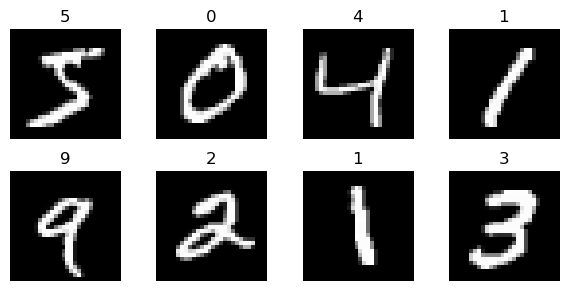

In [41]:
plt.figure(figsize=(6,3))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(str(y_train[i]))
    plt.axis("off")
plt.tight_layout()
plt.show()


### TODO 1 — Normalize & Flatten
- Normalize images to [0,1]
- Flatten to shape `(num_samples, 784)`


In [42]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [43]:
# TODO 1:
# 1) x_train, x_test -> float32 and divide by 255.0
# 2) flatten to (num_samples, 784)

x_train = x_train.astype(float) / 255.0
x_test  = x_test.astype(float) / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print("New train shape:", None if x_train is None else x_train.shape)
print("New test  shape:", None if x_test  is None else x_test.shape)


New train shape: (60000, 784)
New test  shape: (10000, 784)


### TODO 2 — Build the ANN model
Build a `Sequential` model:
- Dense(128, relu)
- Dense(64, relu)
- Dense(10, softmax)


In [44]:
# TODO 2:
model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### Train & Evaluate

In [45]:
# Compile
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1
)


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8982 - loss: 0.3685 - val_accuracy: 0.9575 - val_loss: 0.1519
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9564 - loss: 0.1511 - val_accuracy: 0.9657 - val_loss: 0.1151
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9692 - loss: 0.1031 - val_accuracy: 0.9675 - val_loss: 0.1094
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9768 - loss: 0.0787 - val_accuracy: 0.9745 - val_loss: 0.0885
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9811 - loss: 0.0612 - val_accuracy: 0.9742 - val_loss: 0.0872


In [46]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print("MNIST Test accuracy:", test_acc)


MNIST Test accuracy: 0.9700000286102295


### Reflection (write your answers)
1. Why do we flatten images for ANN?
2. What information do we lose when flattening?


In [ ]:
# TODO (optional): write your reflection here as comments.
# 1. we are working with normal neural network, and out input image is 2D, the normal neural
# are not able to decode this information directly so we need to flatten this to work with 1D
# 2. we lose spatial correlation the relation with pixels with each other in the 2D can not be represented in the 1D

---
## Part 2 — ANN on CIFAR-10
### Objective
- Load CIFAR-10 (32x32 RGB)
- Normalize and flatten for ANN
- Observe performance drop compared to MNIST


In [52]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)

# y is shape (N,1) for CIFAR-10; flatten it to (N,)
y_train = y_train.squeeze()
y_test  = y_test.squeeze()


Train: (50000, 32, 32, 3) (50000, 1)
Test : (10000, 32, 32, 3) (10000, 1)


### Visualize a few CIFAR-10 samples

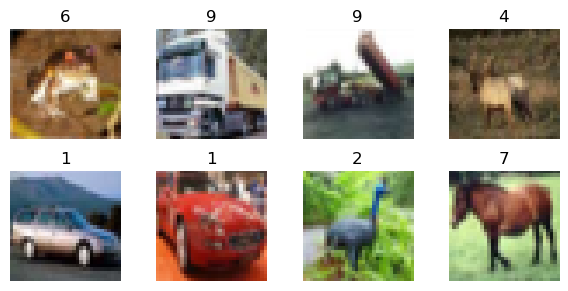

In [53]:
plt.figure(figsize=(6,3))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(x_train[i])
    plt.title(str(y_train[i]))
    plt.axis("off")
plt.tight_layout()
plt.show()


### TODO 3 — Normalize & Flatten CIFAR-10
- Normalize to [0,1]
- Flatten to `(num_samples, 32*32*3)`


In [54]:
# TODO 3:
x_train = x_train.astype(float) / 255.0
x_test  = x_test.astype(float) / 255.0

print("New train shape:", None if x_train is None else x_train.shape)
print("New test  shape:", None if x_test  is None else x_test.shape)


New train shape: (50000, 32, 32, 3)
New test  shape: (10000, 32, 32, 3)


In [55]:
x_train = x_train.reshape(-1, 32*32*3)
x_test = x_test.reshape(-1, 32*32*3)

### TODO 4 — Rebuild ANN for CIFAR-10
Use the same architecture idea, but ensure the input shape matches.


In [57]:
# TODO 4:
model = keras.Sequential([
    layers.Input(shape=(32*32*3,)),
    layers.Dense(1024, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print("CIFAR-10 (ANN) Test accuracy:", test_acc)


Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.3014 - loss: 1.9228 - val_accuracy: 0.3726 - val_loss: 1.7573
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.3860 - loss: 1.7013 - val_accuracy: 0.4058 - val_loss: 1.6665
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.4204 - loss: 1.6127 - val_accuracy: 0.4246 - val_loss: 1.6005
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.4445 - loss: 1.5513 - val_accuracy: 0.4452 - val_loss: 1.5629
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4670 - loss: 1.4958 - val_accuracy: 0.4698 - val_loss: 1.4970
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4766 - loss: 1.4649 - val_accuracy: 0.4570 - val_loss: 1.5260
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4900 - loss: 1.4259 - val_accuracy: 0.4748 - val_loss: 1.4535
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5018 - loss: 1.3921 - val_accu

### Reflection
1. Why did accuracy drop compared to MNIST?
2. What should we use instead of flattening for images?


In [ ]:
# TODO: your answers
# due to the complexity on the image which need to decode spatial relation in the data
# we could use cnn

---
## Part 3 — CNN on CIFAR-10
### Objective
- Train a CNN on the same CIFAR-10 data
- Compare performance vs ANN


In [58]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalize (no flatten!)
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

y_train = y_train.squeeze()
y_test  = y_test.squeeze()

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)


Train: (50000, 32, 32, 3) (50000,)
Test : (10000, 32, 32, 3) (10000,)


### TODO 5 — Build the CNN
Suggested architecture:
- Conv2D(32, 3x3, relu) + MaxPool
- Conv2D(64, 3x3, relu) + MaxPool
- Flatten
- Dense(64, relu)
- Dense(10, softmax)


In [59]:
# TODO 5:
model = keras.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.Conv2D(32, 3, activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print("CIFAR-10 (CNN) Test accuracy:", test_acc)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,616,490 (6.17 MB)

 Trainable params: 1,616,490 (6.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.4692 - loss: 1.4873 - val_accuracy: 0.5736 - val_loss: 1.2305
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.6058 - loss: 1.1236 - val_accuracy: 0.6038 - val_loss: 1.1315
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.6658 - loss: 0.9551 - val_accuracy: 0.6342 - val_loss: 1.0381
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.7136 - loss: 0.8231 - val_accuracy: 0.6414 - val_loss: 1.0272
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.7511 - loss: 0.7148 - val_accuracy: 0.6544 - val_loss: 1.0362
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.7956 - loss: 0.5970 - val_accuracy: 0.6444 - val_loss: 1.0823
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8282 - loss: 0.4954 - val_accuracy: 0.6536 - val_loss: 1.1366
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8646 - loss: 0.3973 - val_accu

In [61]:
# TODO 5:
model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.35),

    layers.Conv2D(256, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.40),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax"),
])

model.summary()

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print("CIFAR-10 (CNN) Test accuracy:", test_acc)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 256)      │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 256)      │       589,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 1,216,458 (4.64 MB)

 Trainable params: 1,214,666 (4.63 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 92s 258ms/step - accuracy: 0.4521 - loss: 1.4926 - val_accuracy: 0.0986 - val_loss: 7.3004
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 92s 262ms/step - accuracy: 0.6274 - loss: 1.0452 - val_accuracy: 0.2774 - val_loss: 2.5159
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 90s 255ms/step - accuracy: 0.6835 - loss: 0.8931 - val_accuracy: 0.5928 - val_loss: 1.2941
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 91s 258ms/step - accuracy: 0.7241 - loss: 0.7942 - val_accuracy: 0.6296 - val_loss: 1.0825
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 90s 256ms/step - accuracy: 0.7550 - loss: 0.7113 - val_accuracy: 0.6512 - val_loss: 1.0561
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 91s 260ms/step - accuracy: 0.7809 - loss: 0.6397 - val_accuracy: 0.7004 - val_loss: 0.9095
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 98s 280ms/step - accuracy: 0.7966 - loss: 0.5901 - val_accuracy: 0.7442 - val_loss: 0.7603
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 103s 292ms/step - accuracy: 0.8160 - loss: 

### Final Questions
1. Why does CNN usually outperform ANN on image data?
2. What is the role of convolution? pooling?
3. If you increase depth/filters, what might happen to overfitting?


In [ ]:
# TODO: your answers
#1. because it is able to decode the spatial relation and learn global and local features
# of the image, which is not feasible by ANN
#2. aim of convultion is to learn a kernal that we can use to identify local and global features in the images
#2. objective of pooling is to decrease the dim, identify the features that contribute more the output
#3. it will lead that the model training accuracy can be great but can fail during validation